# AdaBoost

This notebook is the AdaBoost part of the final project. It is written to be useful in the report and presentation, not only as a code dump. The notebook reads the saved project outputs from `results/` and `figures/`, then adds a small interactive view for the AdaBoost scaling curves.

Main focus:

- explain the from-scratch AdaBoost implementation used in `src/boosting/adaboost.py`
- inspect the staged train/test behavior from `results/adaboost_scaling.csv`
- show the saved AdaBoost figures from the shared `figures/` folder
- connect AdaBoost results to head-to-head, bias-variance, and GBM comparison artifacts
- provide a slider-based live plot for the bonus interactive-notebook requirement

The notebook is artifact-first. It does not rerun the full experiment suite.

## 1. Setup

Run this notebook from the repository root, or open it from the `notebooks/` folder. The path detection below finds the project root automatically in both cases.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

%matplotlib inline

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists() and (candidate / "results").exists():
        ROOT = candidate
        break

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"

print(f"Project root: {ROOT}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

Project root: C:\Users\User\OneDrive\Desktop\zero-bias-boosting-vs-bagging
Results dir:  C:\Users\User\OneDrive\Desktop\zero-bias-boosting-vs-bagging\results
Figures dir:  C:\Users\User\OneDrive\Desktop\zero-bias-boosting-vs-bagging\figures


## 2. What our AdaBoost implementation does

The project implementation uses decision stumps as weak learners and combines them with the discrete SAMME AdaBoost voting rule. In simple terms, each stump is trained with sample weights; after each round, misclassified points receive more attention in the next round. The final prediction is an alpha-weighted vote across all stumps.

Important implementation details:

- `AdaBoostClassifier` is implemented from scratch in `src/boosting/adaboost.py`.
- The weak learner is a weighted `DecisionStump`.
- `estimator_errors_` stores each round's weighted training error.
- `estimator_weights_` stores each stump's alpha value.
- `staged_predict(...)` gives predictions after each boosting round, which is what the scaling experiment uses to draw train/test curves.

## 3. Load saved AdaBoost scaling results

These results are produced by `python -m src.experiments.adaboost_scaling`. The experiment varies the number of estimators and records staged train/test accuracy and macro F1.

In [2]:
scaling_csv = RESULTS_DIR / "adaboost_scaling.csv"
scaling_json = RESULTS_DIR / "adaboost_scaling.json"

if not scaling_csv.exists():
    raise FileNotFoundError(f"Missing required file: {scaling_csv}")
if not scaling_json.exists():
    raise FileNotFoundError(f"Missing required file: {scaling_json}")

scaling = pd.read_csv(scaling_csv)
with scaling_json.open("r", encoding="utf-8") as f:
    scaling_payload = json.load(f)

display(scaling.head())
print(f"Rows loaded: {len(scaling)}")
print(f"Datasets: {', '.join(sorted(scaling['dataset'].unique()))}")

,dataset,task,n_estimators,train_accuracy,test_accuracy,train_error,test_error,train_macro_f1,test_macro_f1
0,wdbc,binary,1,0.929670,0.877193,0.070330,0.122807,0.923728,0.859951
1,wdbc,binary,5,0.958242,0.947368,0.041758,0.052632,0.955548,0.942230
2,wdbc,binary,10,0.975824,0.938596,0.024176,0.061404,0.973951,0.931367
3,wdbc,binary,15,0.982418,0.956140,0.017582,0.043860,0.981127,0.951576
4,wdbc,binary,20,0.995604,0.947368,0.004396,0.052632,0.995293,0.941538


Rows loaded: 123
Datasets: adult, covertype, wdbc


## 4. Best-round summary

This table is useful for the report because it shows where the test score peaks, and whether the final round moved far away from that best point.

In [3]:
summary_rows = []

for dataset_name, group in scaling.groupby("dataset"):
    group = group.sort_values("n_estimators")
    best = group.loc[group["test_accuracy"].idxmax()]
    final = group.iloc[-1]
    summary_rows.append(
        {
            "dataset": dataset_name,
            "best_estimators": int(best["n_estimators"]),
            "best_test_accuracy": best["test_accuracy"],
            "best_test_macro_f1": best["test_macro_f1"],
            "final_estimators": int(final["n_estimators"]),
            "final_test_accuracy": final["test_accuracy"],
            "final_test_macro_f1": final["test_macro_f1"],
            "late_accuracy_drop": best["test_accuracy"] - final["test_accuracy"],
        }
    )

adaboost_summary = pd.DataFrame(summary_rows).sort_values("dataset")
display(adaboost_summary.round(4))

,dataset,best_estimators,best_test_accuracy,best_test_macro_f1,final_estimators,final_test_accuracy,final_test_macro_f1,late_accuracy_drop
0,adult,160,0.8530,0.7781,200,0.8530,0.7781,0.0000
1,covertype,55,0.5280,0.3407,200,0.4400,0.3544,0.0880
2,wdbc,30,0.9825,0.9810,200,0.9737,0.9713,0.0088


## 5. Static figures saved by the experiment

The official project figures are stored in the shared `figures/` folder. This keeps the notebook, report, and slides all pointing to the same visual outputs.

### adult

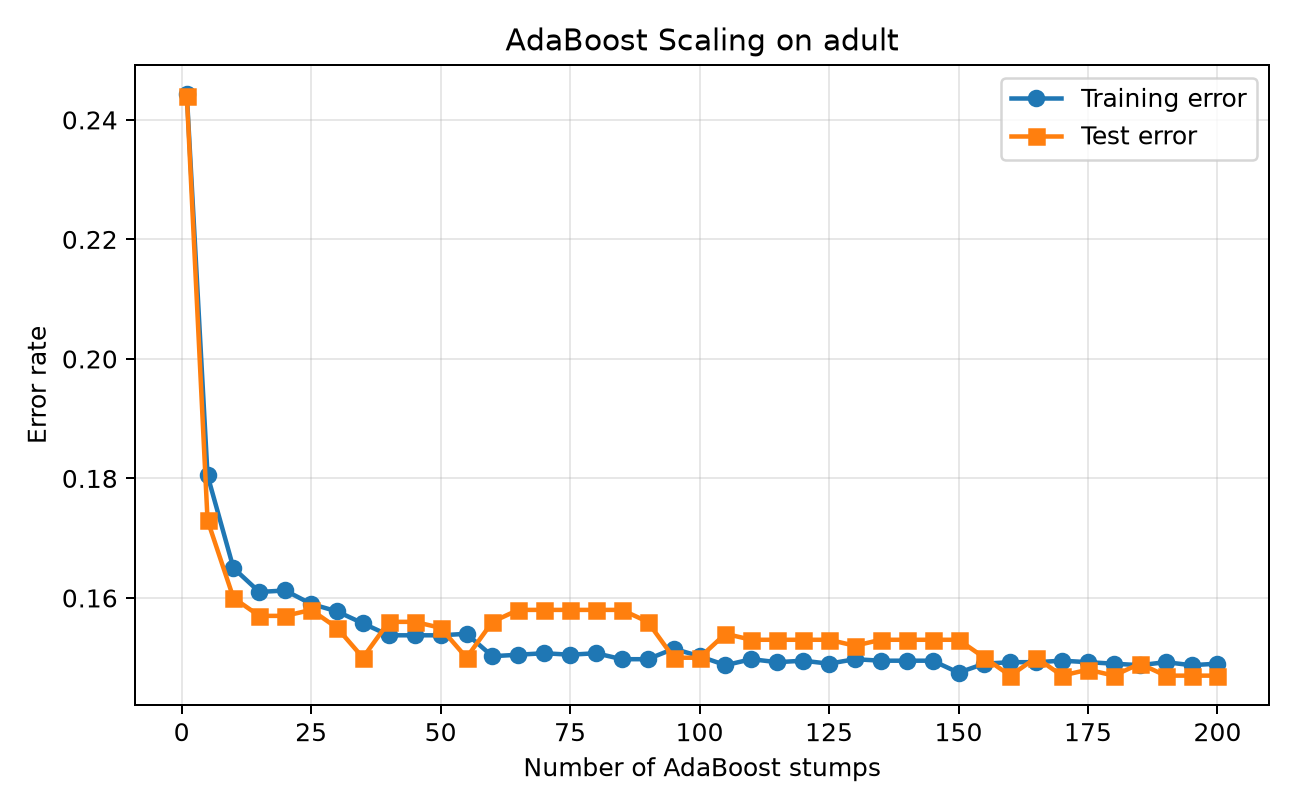

### covertype

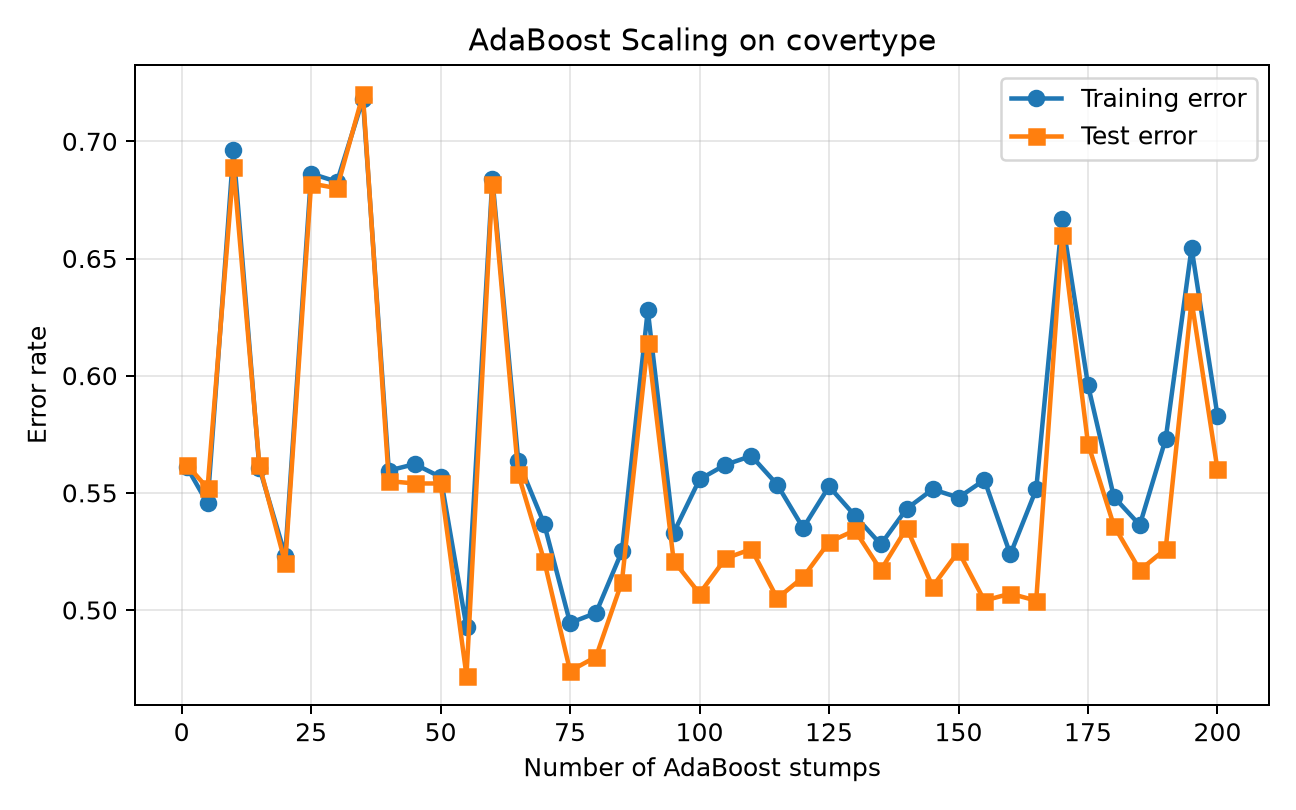

### wdbc

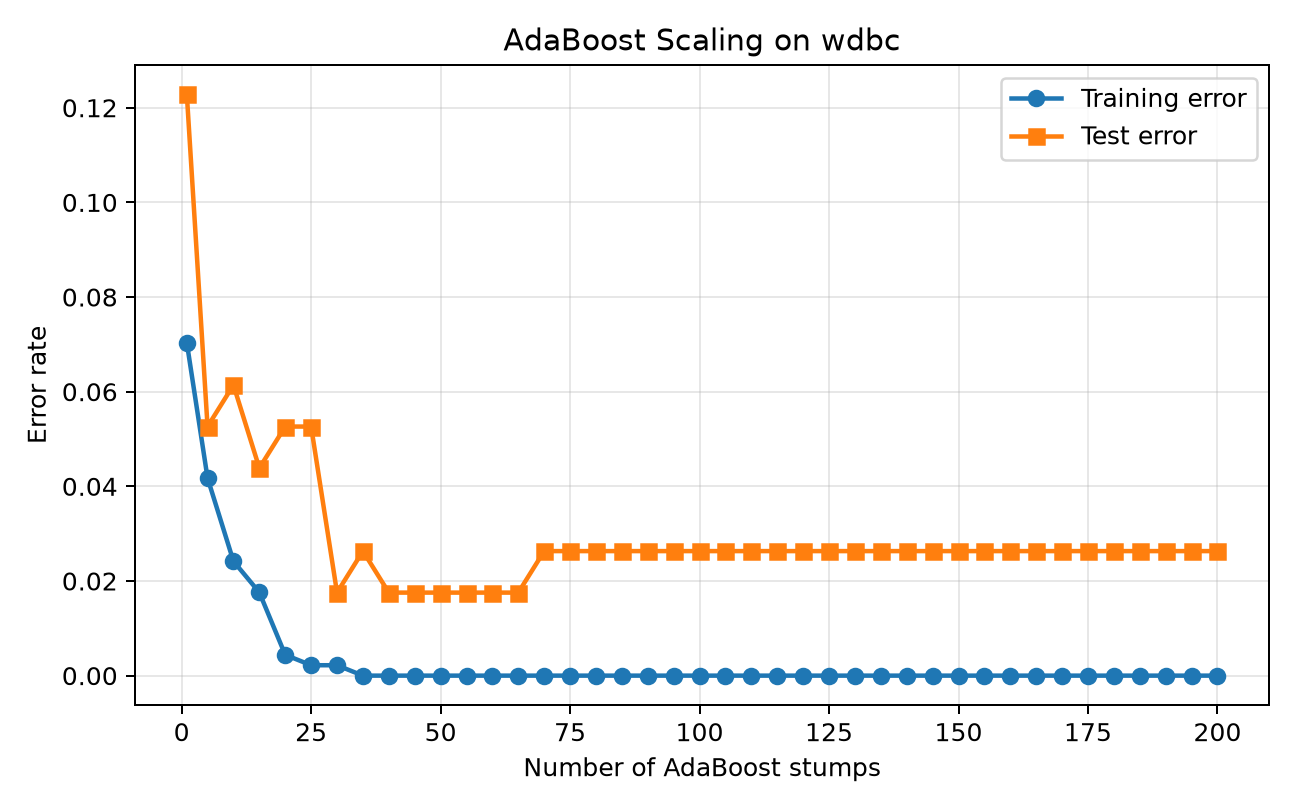

In [4]:
figure_paths = scaling_payload.get("figure_paths", {})

for dataset_name in sorted(figure_paths):
    rel_path = Path(figure_paths[dataset_name])
    figure_path = ROOT / rel_path
    display(Markdown(f"### {dataset_name}"))
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
    else:
        print(f"Missing figure: {figure_path}")

## 6. Interactive AdaBoost scaling plot

Use the dataset selector and estimator slider to inspect how train/test error changes as more stumps are added. If `ipywidgets` is not installed, the cell falls back to a normal static plot instead of failing.

In [5]:
def plot_scaling_curve(dataset_name, max_estimators=None):
    subset = scaling[scaling["dataset"] == dataset_name].sort_values("n_estimators")
    if max_estimators is not None:
        subset = subset[subset["n_estimators"] <= max_estimators]

    if subset.empty:
        print(f"No rows available for {dataset_name}.")
        return

    best = subset.loc[subset["test_accuracy"].idxmax()]
    latest = subset.iloc[-1]

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.plot(subset["n_estimators"], subset["train_error"], marker="o", linewidth=2, label="Train error")
    ax.plot(subset["n_estimators"], subset["test_error"], marker="s", linewidth=2, label="Test error")
    ax.axvline(best["n_estimators"], color="tab:green", linestyle="--", linewidth=1.5, label="Best visible test accuracy")
    ax.set_title(f"AdaBoost scaling on {dataset_name}")
    ax.set_xlabel("Number of stumps")
    ax.set_ylabel("Error rate")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    plt.show()

    display(
        pd.DataFrame(
            [
                {
                    "shown_up_to_estimators": int(latest["n_estimators"]),
                    "best_visible_estimators": int(best["n_estimators"]),
                    "best_visible_test_accuracy": best["test_accuracy"],
                    "latest_visible_test_accuracy": latest["test_accuracy"],
                    "latest_visible_test_macro_f1": latest["test_macro_f1"],
                }
            ]
        ).round(4)
    )


dataset_options = sorted(scaling["dataset"].unique())
estimator_values = sorted(int(value) for value in scaling["n_estimators"].unique())
max_rounds = max(estimator_values)
slider_step = max(1, estimator_values[1] - estimator_values[0]) if len(estimator_values) > 1 else 1

try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    dataset_dropdown = widgets.Dropdown(options=dataset_options, value=dataset_options[0], description="Dataset")
    estimator_slider = widgets.IntSlider(
        value=max_rounds,
        min=min(estimator_values),
        max=max_rounds,
        step=slider_step,
        description="Stumps",
        continuous_update=False,
    )
    output = widgets.Output()

    def refresh_plot(*_):
        with output:
            clear_output(wait=True)
            plot_scaling_curve(dataset_dropdown.value, estimator_slider.value)

    dataset_dropdown.observe(refresh_plot, names="value")
    estimator_slider.observe(refresh_plot, names="value")
    display(widgets.VBox([widgets.HBox([dataset_dropdown, estimator_slider]), output]))
    refresh_plot()
except ImportError:
    print("ipywidgets is not installed. Install it with: pip install ipywidgets")
    print("Static fallback is shown below.")
    plot_scaling_curve(dataset_options[0], max_rounds)

## 7. Small implementation diagnostic on WDBC

This cell trains a small AdaBoost model on WDBC only. It is intentionally small, so it is suitable for live explanation. It shows the internal round-by-round weighted error and alpha values stored by our implementation.

,round,weighted_error,alpha
0,1,0.0703,2.5816
1,2,0.1581,1.6725
2,3,0.1770,1.5367
3,4,0.2369,1.1695
4,5,0.2296,1.2107
5,6,0.2408,1.1481
6,7,0.2716,0.9866
7,8,0.2818,0.9356
8,9,0.2970,0.8618
9,10,0.2850,0.9199


Demo train accuracy: 0.9978
Demo test accuracy:  0.9825


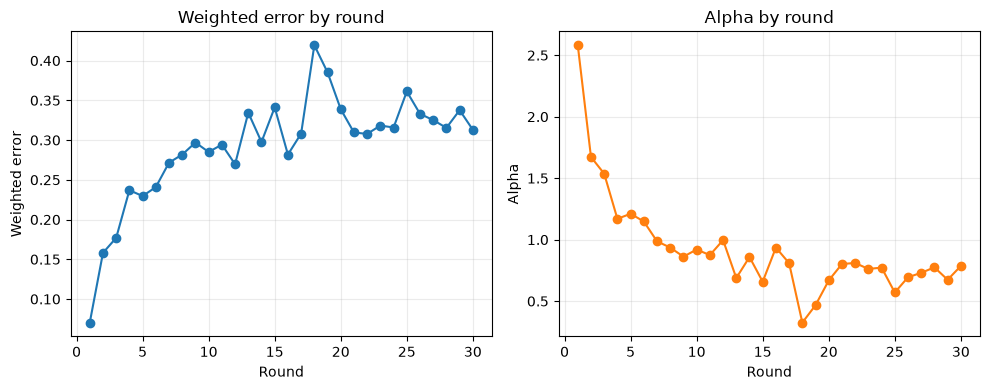

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.boosting.adaboost import AdaBoostClassifier
from src.utils.preprocessing import load_project_datasets

try:
    wdbc = load_project_datasets(names=("wdbc",), data_dir=ROOT / "data")[0]
except FileNotFoundError as exc:
    print(f"Could not load WDBC from local project data: {exc}")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        wdbc.X,
        wdbc.y,
        test_size=0.2,
        random_state=42,
        stratify=wdbc.y,
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    demo_model = AdaBoostClassifier(n_estimators=30, random_state=42)
    demo_model.fit(X_train_scaled, y_train)

    diagnostics = pd.DataFrame(
        {
            "round": np.arange(1, len(demo_model.estimator_weights_) + 1),
            "weighted_error": demo_model.estimator_errors_,
            "alpha": demo_model.estimator_weights_,
        }
    )

    display(diagnostics.head(10).round(4))
    print(f"Demo train accuracy: {demo_model.score(X_train_scaled, y_train):.4f}")
    print(f"Demo test accuracy:  {demo_model.score(X_test_scaled, y_test):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(diagnostics["round"], diagnostics["weighted_error"], marker="o")
    axes[0].set_title("Weighted error by round")
    axes[0].set_xlabel("Round")
    axes[0].set_ylabel("Weighted error")
    axes[0].grid(alpha=0.25)

    axes[1].plot(diagnostics["round"], diagnostics["alpha"], marker="o", color="tab:orange")
    axes[1].set_title("Alpha by round")
    axes[1].set_xlabel("Round")
    axes[1].set_ylabel("Alpha")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. AdaBoost inside the wider project comparison

The cells below read the existing comparison artifacts. They are useful, because they show how AdaBoost behaves against the other models without taking over the final-comparison notebook.

In [7]:
head_to_head_path = RESULTS_DIR / "head_to_head_folds.csv"

if head_to_head_path.exists():
    folds = pd.read_csv(head_to_head_path)
    ada_folds = folds[folds["model"].str.contains("AdaBoost", case=False, na=False)]
    metric_cols = ["accuracy", "macro_f1", "roc_auc", "log_loss", "brier_score"]
    available_metrics = [col for col in metric_cols if col in ada_folds.columns]
    ada_cv_summary = (
        ada_folds.groupby(["dataset", "model"])[available_metrics]
        .agg(["mean", "std"])
        .round(4)
    )
    display(ada_cv_summary)
else:
    print(f"Optional comparison file not found: {head_to_head_path}")

accuracy         macro_f1          \
                                             mean     std     mean     std   
dataset   model                                                              
adult     AdaBoost (ours)                  0.8484  0.0072   0.7738  0.0146   
          AdaBoost SAMME.R (ours, bonus)   0.8558  0.0111   0.7897  0.0185   
covertype AdaBoost (ours)                  0.4834  0.0207   0.3591  0.0745   
          AdaBoost SAMME.R (ours, bonus)   0.4456  0.0529   0.3892  0.0633   
wdbc      AdaBoost (ours)                  0.9666  0.0200   0.9639  0.0217   
          AdaBoost SAMME.R (ours, bonus)   0.9701  0.0220   0.9677  0.0239   

                                         roc_auc         log_loss          \
                                            mean     std     mean     std   
dataset   model                                                             
adult     AdaBoost (ours)                 0.9060  0.0077   0.3184  0.0097   
          AdaBoost SAMME.R (ours, bonus)  0.9127  0.0103   0.3087  0.0181   
covertype AdaBoost (ours)                 0.8643  0.0157   1.3462  0.1990   
          AdaBoost SAMME.R (ours, bonus)  0.8698  0.0157   5.1587  0.7560   
wdbc      AdaBoost (ours)                 0.9934  0.0069   0.2371  0.1678   
          AdaBoost SAMME.R (ours, bonus)  0.9954  0.0037   0.2786  0.2272   

                                         brier_score          
                                                mean     std  
dataset   model                                               
adult     AdaBoost (ours)                     0.2062  0.0082  
          AdaBoost SAMME.R (ours, bonus)      0.1976  0.0113  
covertype AdaBoost (ours)                     0.7322  0.0745  
          AdaBoost SAMME.R (ours, bonus)      1.0199  0.0948  
wdbc      AdaBoost (ours)                     0.0641  0.0336  
          AdaBoost SAMME.R (ours, bonus)      0.0546  0.0377

In [8]:
bias_variance_path = RESULTS_DIR / "bias_variance.csv"

if bias_variance_path.exists():
    bias_variance = pd.read_csv(bias_variance_path)
    ada_bias_variance = bias_variance[bias_variance["model"].str.contains("AdaBoost", case=False, na=False)]
    display(ada_bias_variance.round(4))
else:
    print(f"Optional bias-variance file not found: {bias_variance_path}")

,dataset,model,expected_loss,bias_squared,variance
1,wdbc,AdaBoost (ours),0.0328,0.0246,0.0199


In [9]:
gbm_path = RESULTS_DIR / "gbm_comparison.csv"

if gbm_path.exists():
    gbm = pd.read_csv(gbm_path)
    if "split" in gbm.columns:
        gbm = gbm[gbm["split"] == "test"]
    mask = gbm["model"].str.contains("AdaBoost|Gradient Boosting", case=False, na=False, regex=True)
    cols = [col for col in ["dataset", "model", "accuracy", "macro_f1", "roc_auc", "log_loss"] if col in gbm.columns]
    display(gbm.loc[mask, cols].round(4))
else:
    print(f"Optional GBM comparison file not found: {gbm_path}")

,dataset,model,accuracy,macro_f1,roc_auc,log_loss
1,wdbc,AdaBoost (ours),0.9737,0.9713,0.9854,0.3282
3,wdbc,"Gradient Boosting (ours, bonus)",0.9561,0.9516,0.9934,0.1992
5,wdbc,Gradient Boosting (sklearn reference only),0.9649,0.9615,0.9944,0.1280
7,adult,AdaBoost (ours),0.8500,0.7724,0.9070,0.3153
9,adult,"Gradient Boosting (ours, bonus)",0.8530,0.7733,0.8950,0.3686
11,adult,Gradient Boosting (sklearn reference only),0.8550,0.7803,0.9133,0.3091
13,covertype (1 vs 3),AdaBoost (ours),0.9977,0.9977,0.9999,0.0628
15,covertype (1 vs 3),"Gradient Boosting (ours, bonus)",0.9977,0.9977,0.9972,0.1113
17,covertype (1 vs 3),Gradient Boosting (sklearn reference only),0.9977,0.9977,0.9995,0.0239
19,mnist_3_vs_8,AdaBoost (ours),0.9650,0.9650,0.9944,0.1368


## 9. Report and presentation notes

A clean way to present the AdaBoost part:

- AdaBoost starts with simple decision stumps and improves them by reweighting difficult samples.
- The staged curves show the main behavior: training error usually falls as more stumps are added, while test error tells us whether more boosting still helps.
- WDBC is the strongest AdaBoost result in the saved scaling run.
- Adult is harder because the tabular/categorical feature space is larger after preprocessing.
- Covertype is also harder because the subset has more overlap between classes.
- In the wider comparison, AdaBoost is a strong project implementation baseline for boosting, while GBM is included as an additional bonus comparison.

For reproducibility, regenerate the AdaBoost artifacts with:

```powershell
python -m src.experiments.adaboost_scaling
```

To regenerate the full project results:

```powershell
python -m src.experiments.run_all --include-optional
```